# Домашнее задание 7. Сборка конвейера CI/CD
Если у вас еще нет аккаунта в GitLab, вам нужно будет его создать:
1. Перейдите на [GitLab](https://gitlab.com/) и войдите в свой аккаунт.
2. Нажмите на кнопку New Project (Новый проект).
3. Выберите Create blank project (Создать пустой проект).
4. Укажите имя проекта и описание (по желанию).
5. Выберите уровень видимости проекта (Public).
6. Нажмите Create project (Создать проект).
7. Дополните файл .gitlab-ci.yml необходимыми джобами и отправьте в репозиторий.

## 1. Настроить CI/CD-пайплайн для ML-сервиса с использованием GitLab




Вам нужно вспомнить, какие части ML-проекта вы будете сохранять, чтобы получить воспроизводимый пайплайн.

Вам дан рабочий код пайплайна и черновик файла .gitlab-ci.yml. Перепишите yaml в [ячейке](#scrollTo=s55MrS66JXWs)


*Ожидаемый артефакт: список коммитов в [ячейке](#scrollTo=gErasBmRSHjb) и ссылка на выполненный пайплайн в репозитории в [ячейке](#scrollTo=F0uQqbe3iHqE)*    

In [ ]:
%%sh
git config --global user.email "you@example.com"
git config --global user.name "Your Name"
git init
pip install scikit-learn numpy pandas -qqq
pip freeze > requirements.txt

Initialized empty Git repository in /content/.git/


hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>


In [ ]:
%%writefile ml_pipeline.py
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
iris = load_iris();X = iris.data ;y = iris.target
hyperparameters={"n_estimators":100, "random_state":42}
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(**hyperparameters)
model.fit(X_train, y_train);y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность аccuracy: {accuracy:.2f}')

Overwriting ml_pipeline.py


### Проверяем работоспособность пайплайна

In [ ]:
!python ml_pipeline.py

Точность аccuracy: 1.00


In [2]:
%%writefile ml_pipeline.yaml
name: ML Pipeline

on:
  push:

jobs:
  make-pipeline-reproducible:
    runs-on: ubuntu-latest

    steps:
      - name: Checkout repository
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install dependencies
        run: |
          pip install numpy pandas scikit-learn

      - name: Run ML pipeline
        run: |
          python ml_pipeline.py


Writing ml_pipeline.yaml


In [ ]:
!git add .gitlab-ci.yml ml_pipeline.py
!git commit  -m "build(ml_pipeline.py) добавлен пайплайн GitLab"
!git log

[master cf3cb3c] build(ml_pipeline.py) добавлен пайплайн
 1 file changed, 9 insertions(+)
 create mode 100644 .gitlab-ci.yml
commit cf3cb3c56f0d5674582bdd757066897d653cff31 (HEAD -> master)
Author: Your Name <you@example.com>
Date:   Wed Oct 8 19:26:44 2025 +0000

    build(ml_pipeline.py) добавлен пайплайн

commit c29e7659975b52391b4a07c33a329893f1f8426b
Author: Your Name <you@example.com>
Date:   Wed Oct 8 19:13:08 2025 +0000

    build(ml_pipeline.py) добавлен пайплайн


### Проверка статуса пайплайна

После настройки файла `.gitlab-ci.yml`, вы можете закоммитить изменения и запушить их в репозиторий.

GitLab автоматически запустит пайплайн, и вы сможете наблюдать за его выполнением в разделе CI/CD своего проекта.

Что нужно сделать:

1. Перейдите в свой проект на GitLab.
2. Нажмите на вкладку CI/CD и выберите Pipelines.
3. Вы увидите список запущенных пайплайнов. Нажмите на последний, чтобы увидеть выполнение.
4. Убедитесь, что все джобы выполнены успешно (отмечены зеленым цветом).
5. Приложите ссылку на статус выполнения в разделе Pipelines **своего** репозитория на GitLab.

# Ответ

Так как GitLab не даёт верифицировать аккаунт, а GitVerse требует указания личного номера телефона, то было принято решение работать в gitea, что разрешено заданием:
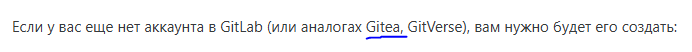

Был создан проект mlops-hw-07: http://212.60.4.180:3000/mipt_iukr_mlops/mlops-hw-07/graph

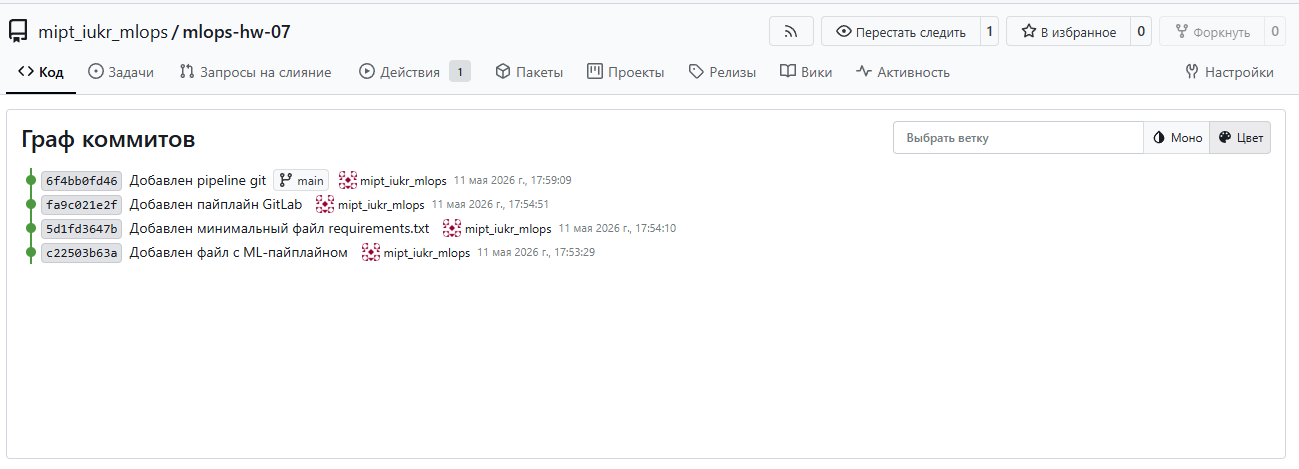


Добавлен файл с ML моделью:
```python
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

hyperparameters = {
    "n_estimators": 100,
    "random_state": 42
}

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(**hyperparameters)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Точность accuracy: {accuracy:.2f}")
```

Добавлен файл requirement.txt с минимальным набором необходимых библиотек

```
numpy
pandas
scikit-learn
```


В специальную папку был добавлен файл .gitea/workflows/ml_pipeline.yaml, который при push должен запускать установку python, установку необходимых библиотек и запуск файла с моделью:

```yaml
name: ML Pipeline

on:
  push:

jobs:
  make-pipeline-reproducible:
    runs-on: ubuntu-latest

    steps:
      - name: Checkout repository
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install dependencies
        run: |
          pip install numpy pandas scikit-learn

      - name: Run ML pipeline
        run: |
          python ml_pipeline.py
```

К сожалению, на данном окружении не было доступных ворекров для проверки работоспособности файла, однако, его содержание совпадает с показанным на консультации
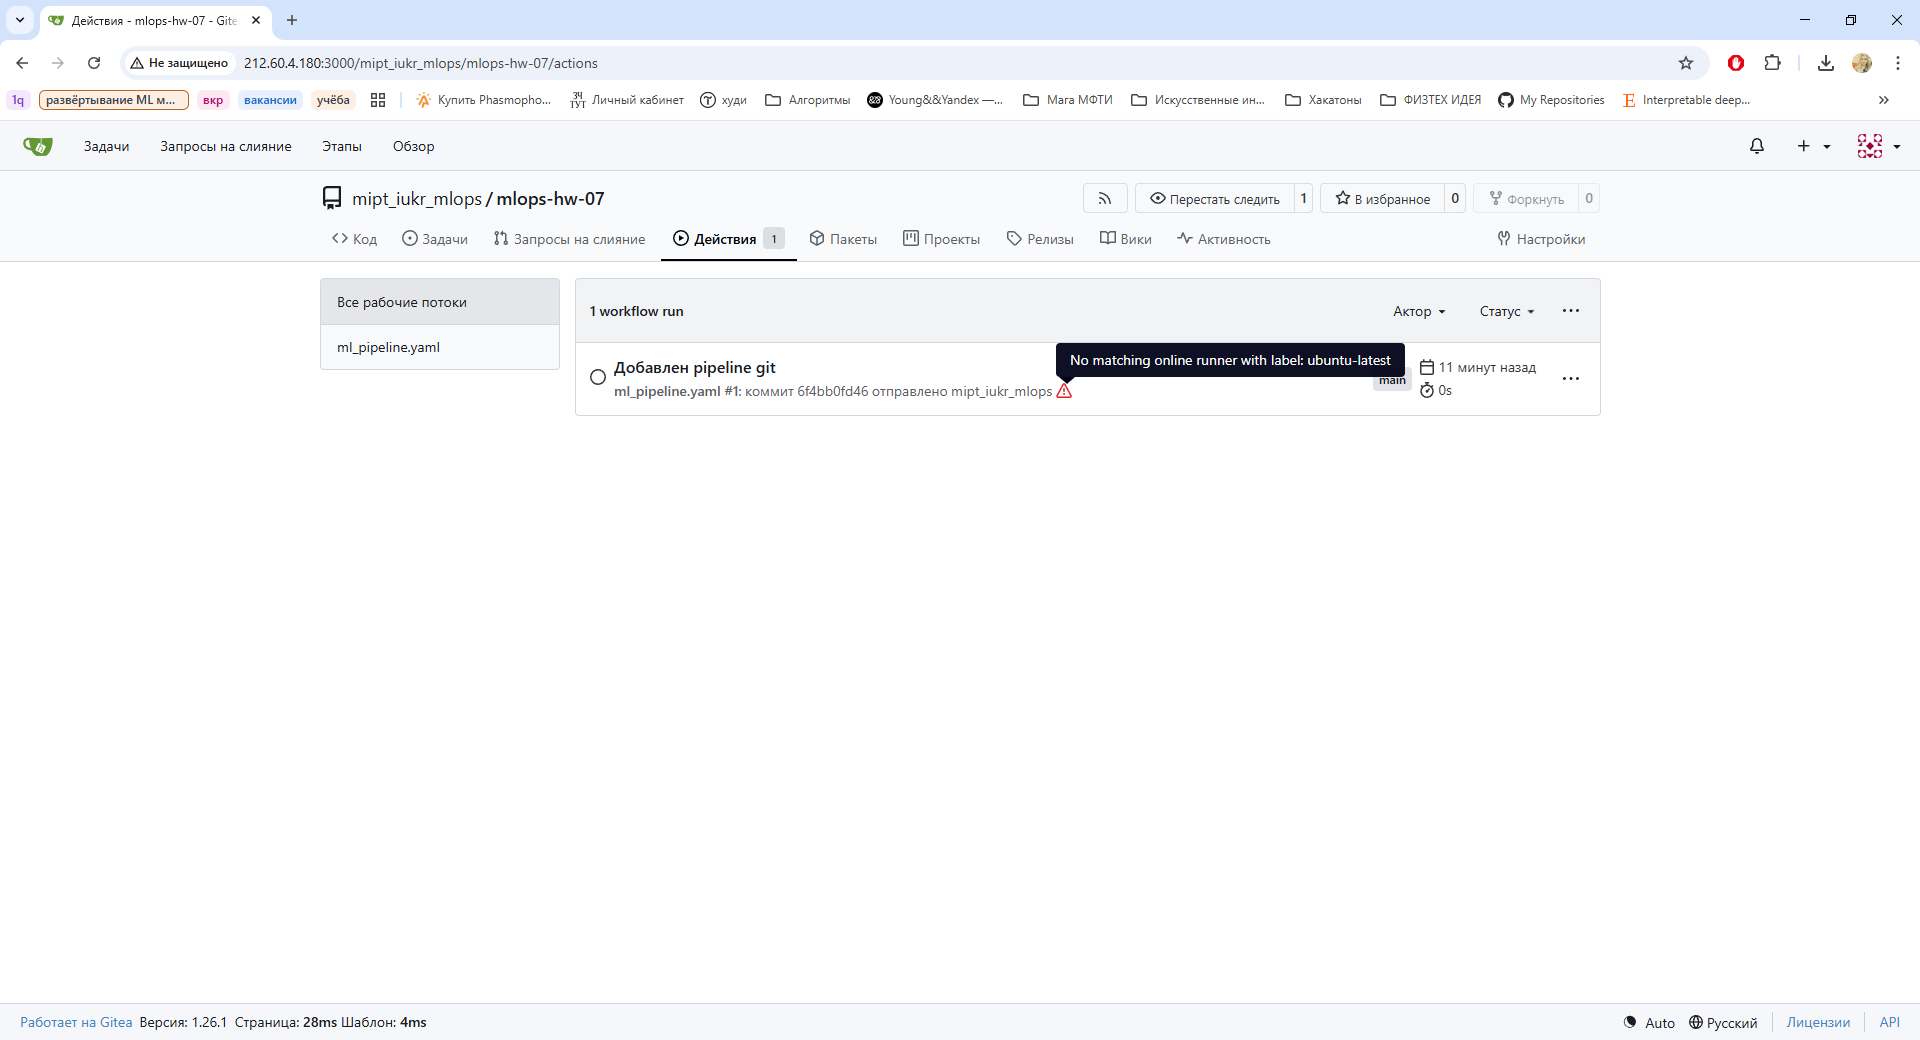

## 2. Обосновать стратегию деплоя (развертывания, Blue-Green, Canary, Rolling, Shadow) и оценить влияние на риски




Изучите [инструмент](https://github.com/npryce/adr-tools) для учета архитектурных решений и запишите **причины**, по которым мы начали использовать стратегию деплоя и **риски**, к которым нас привело такое решение.



*Ожидаемый артефакт: архитектурное решение в формате ADR в текстовой [ячейке](#scrollTo=hycprahZcUrJ)*

Мы начали использовать стратегию деплоя для автоматизации выпуска новых версий сервиса, уменьшения количества ручных ошибок и ускорения доставки изменений в production. Для ML-сервиса наиболее подходящей является стратегия Blue-Green, так как она позволяет быстро переключаться между старой и новой версиями и при необходимости выполнять откат без простоя системы. Такое решение делает процесс развертывания более безопасным и воспроизводимым, однако увеличивает требования к инфраструктуре и создаёт риск рассинхронизации между двумя окружениями.

## 3. Реализовать стратегию развертывания

Реализуйте стратегию, выбранную на предыдущем [шаге](#scrollTo=hoQdM6SrJXXE).



*Ожидаемый артефакт: yaml в текстовой [ячейке](#scrollTo=hycprahZcUrJ)*

In [3]:
%%writefile docker-compose-blue.yaml
version: '3.9'

services:
  app-blue:
    image: python:3.11
    container_name: ml-service-blue
    working_dir: /app
    volumes:
      - ./:/app
    command: python ml_pipeline.py
    ports:
      - "5000:5000"

  app-green:
    image: python:3.11
    container_name: ml-service-green
    working_dir: /app
    volumes:
      - ./:/app
    command: python ml_pipeline.py
    ports:
      - "5001:5000"

Writing docker-compose-blue.yaml


## 4. Спланировать A/B-тестирование для ML-модели

Вспомните материалы [семинара](https://colab.research.google.com/drive/1TM1yieSFhUqVxBferzbcexpAtK00lGYe?usp=sharing) и опишите параметры эксперимента.



*Ожидаемый артефакт: код в [ячейке](#scrollTo=OluzjqEhaIpM)*

In [5]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

np.random.seed(42)

model_a = np.random.binomial(1, 0.82, 1000)
model_b = np.random.binomial(1, 0.87, 1000)

alpha = 0.05
step = 100

for i in range(step, len(model_a) + 1, step):

    successes = [
        np.sum(model_a[:i]),
        np.sum(model_b[:i])
    ]

    observations = [i, i]

    stat, p_value = proportions_ztest(successes, observations)

    print(f"Размер выборки: {i}, p-value = {p_value:.6f}")

    if p_value < alpha:
        print(f"\nЭксперимент остановлен досрочно. p-value = {p_value:.6f}")
        print("Обнаружены статистически значимые различия между моделями.")
        break

else:
    print(f"\nСтатистически значимые различия не обнаружены. Финальный p-value = {p_value:.6f}")

Размер выборки: 100, p-value = 0.269456
Размер выборки: 200, p-value = 0.602660
Размер выборки: 300, p-value = 0.441356
Размер выборки: 400, p-value = 0.565274
Размер выборки: 500, p-value = 0.126066
Размер выборки: 600, p-value = 0.020137

Эксперимент остановлен досрочно. p-value = 0.020137
Обнаружены статистически значимые различия между моделями.


## 5. Создать CI/CD-пайплайн для ML-сервиса с использованием GitHub Actions



*Ожидаемый артефакт: ссылка на выполненный пайплайн в репозитории в [ячейке](#scrollTo=CQG_D73seauF)*



Вам нужно вспомнить, какие части ML-проекта вы будете сохранять, чтобы получить воспроизводимый пайплайн.

In [ ]:
%%writefile ml_pipeline.py
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
iris = load_iris();X = iris.data ;y = iris.target
hyperparameters={"n_estimators":100, "random_state":42}
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(**hyperparameters)
model.fit(X_train, y_train);y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность аccuracy: {accuracy:.2f}')

Overwriting ml_pipeline.py


Проверяем работоспособность пайплайна

In [ ]:
!python ml_pipeline.py

Точность аccuracy: 1.00


Вам дан рабочий код пайплайна и черновик файла ci.yml. Используйте GitHub Actions и перепишите [шаг](#scrollTo=NGcDFbCFJXV_) name: Make pipeline reproducible

In [6]:
%%writefile ci.yml
name: CI
on: [push, pull_request]

jobs:
  build:
    runs-on: ubuntu-latest

    steps:
    - uses: actions/checkout@v2
    - name: Set up Python
      uses: actions/setup-python@v2
      with:
        python-version: '3.x'
    - name: Install dependencies
      run: |
        python -m pip install --upgrade pip
        pip install scikit-learn numpy pandas
    - name: Run pipeline
      run: |
          python ml_pipeline.py


Writing ci.yml


Копируем ci.yml в правильную директорию .github/workflows

In [ ]:
!mkdir -p .github/workflows
!mv ci.yml ./.github/workflows/ci.yml

Начинаем отправку в репозиторий

In [ ]:
!git add ./.github/workflows/ci.yml ml_pipeline.py
!git commit  -m "build(ml_pipeline.py) добавлен пайплайн GitHub Actions"
!git log

[master (root-commit) c29e765] build(ml_pipeline.py) добавлен пайплайн
 2 files changed, 35 insertions(+)
 create mode 100644 .github/workflows/ci.yml
 create mode 100644 ml_pipeline.py
commit c29e7659975b52391b4a07c33a329893f1f8426b (HEAD -> master)
Author: Your Name <you@example.com>
Date:   Wed Oct 8 19:13:08 2025 +0000

    build(ml_pipeline.py) добавлен пайплайн


После настройки workflow каждый раз при пуше в репозиторий GitHub Actions будет автоматически запускать конвейер. Пожалуйста, приложите ссылку на статус выполнения в разделе Actions **своего** репозитория на GitHub.


*Ожидаемый артефакт: ссылка на выполненный пайплайн в репозитории в [ячейке](#scrollTo=CQG_D73seauF)*

# Ответ

Выполненный пайплайн: https://github.com/LenyOstrich/mlops-hw-07/actions/runs/25679912755

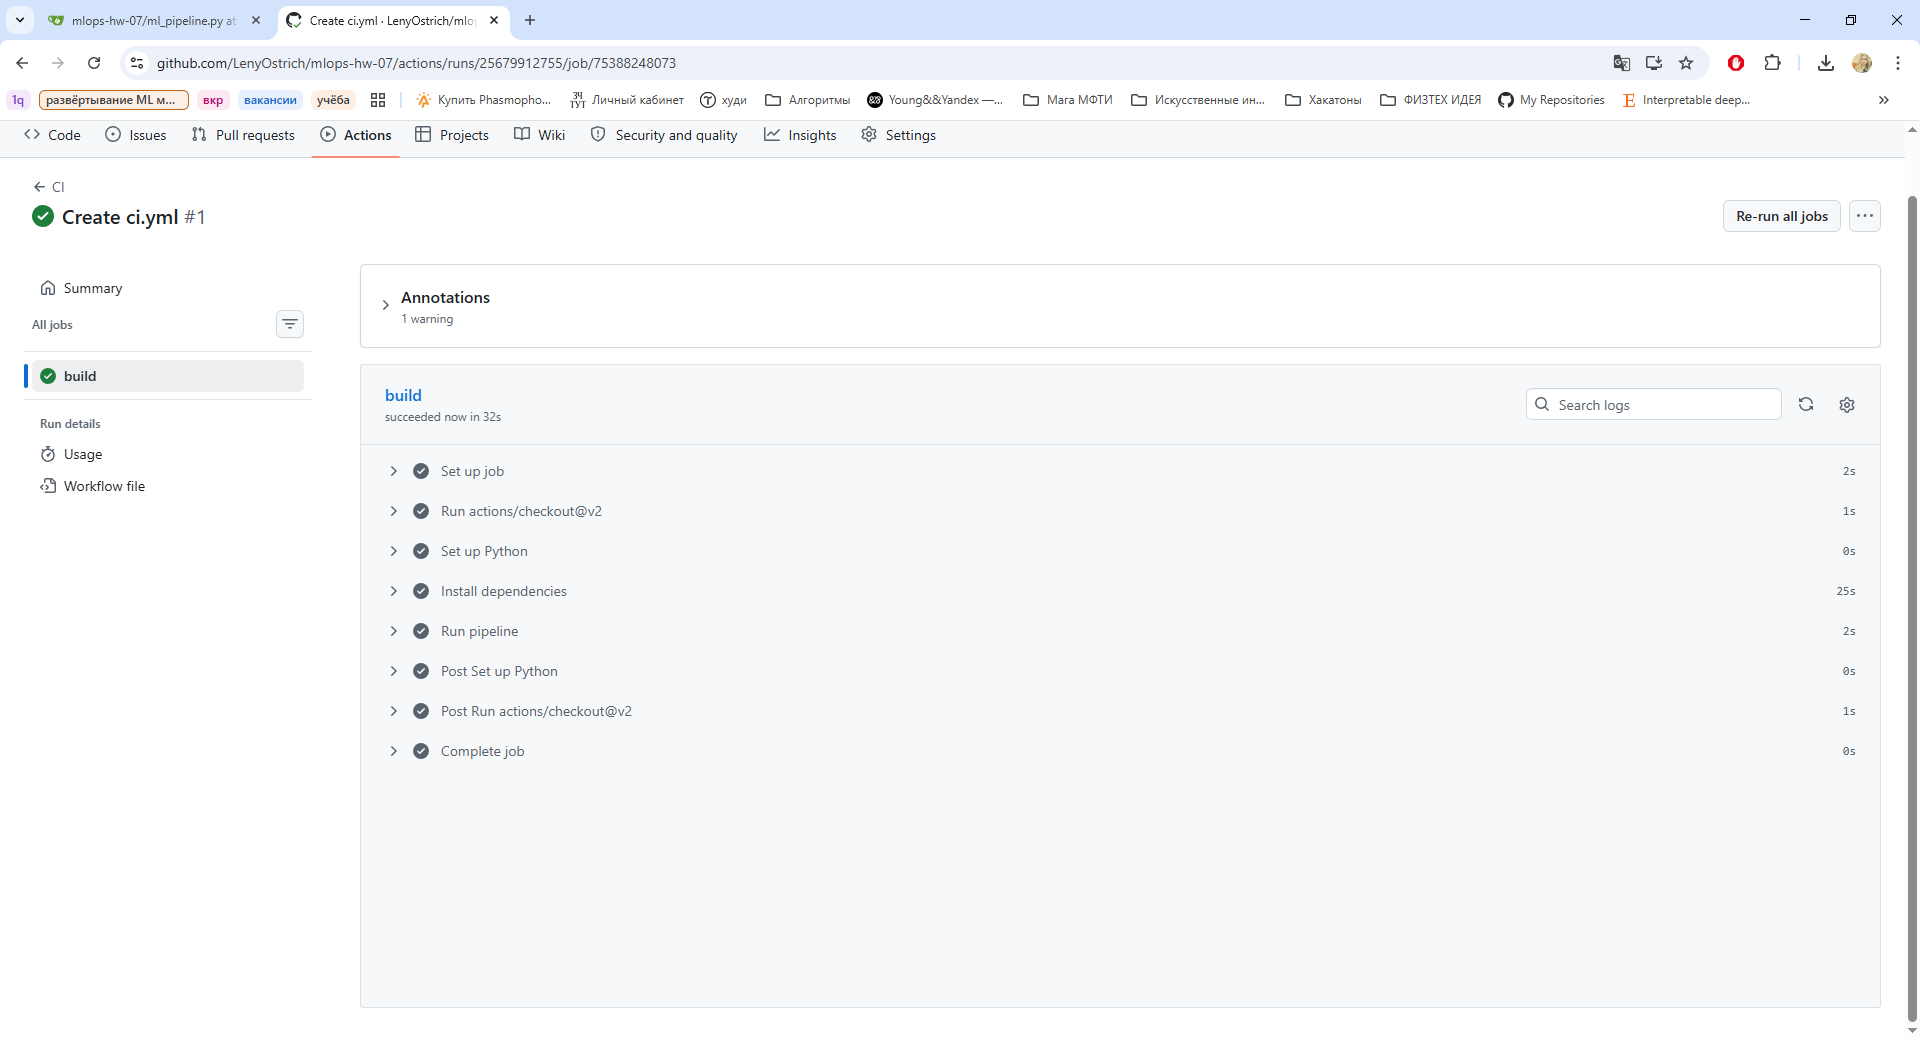


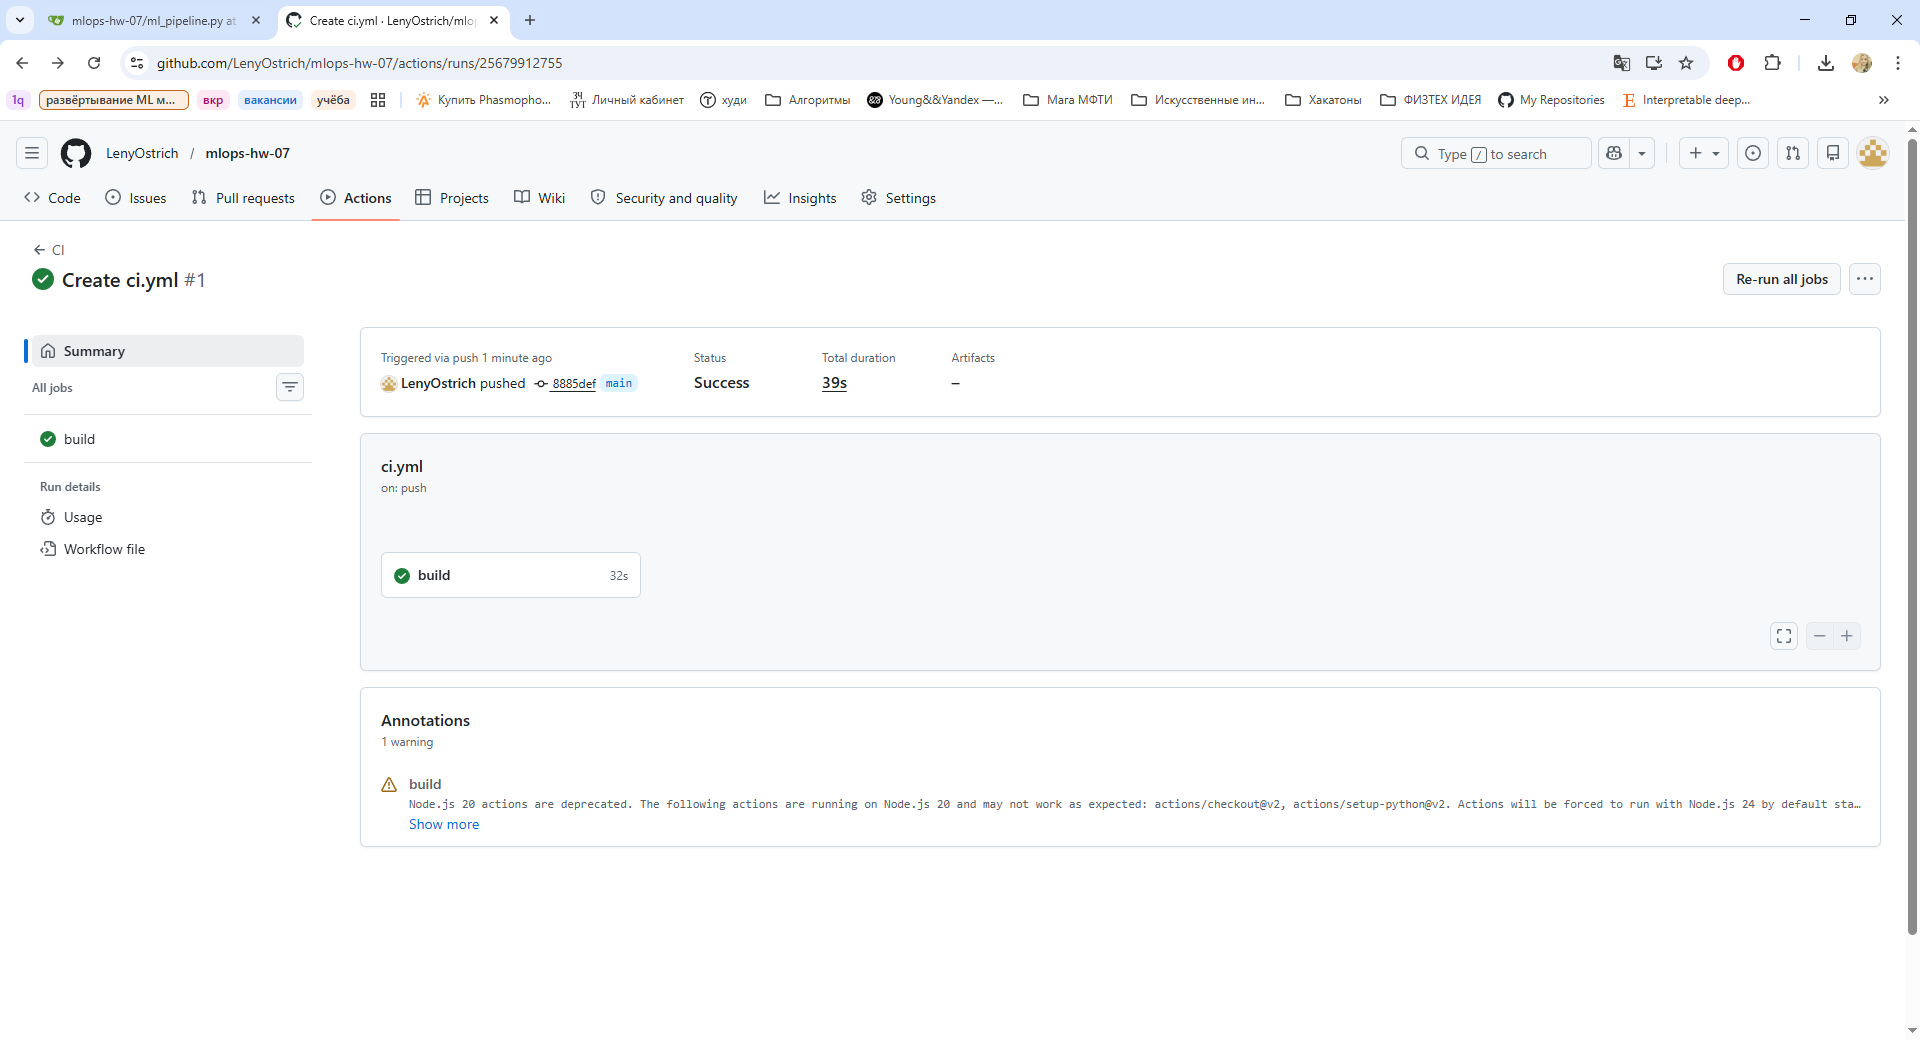

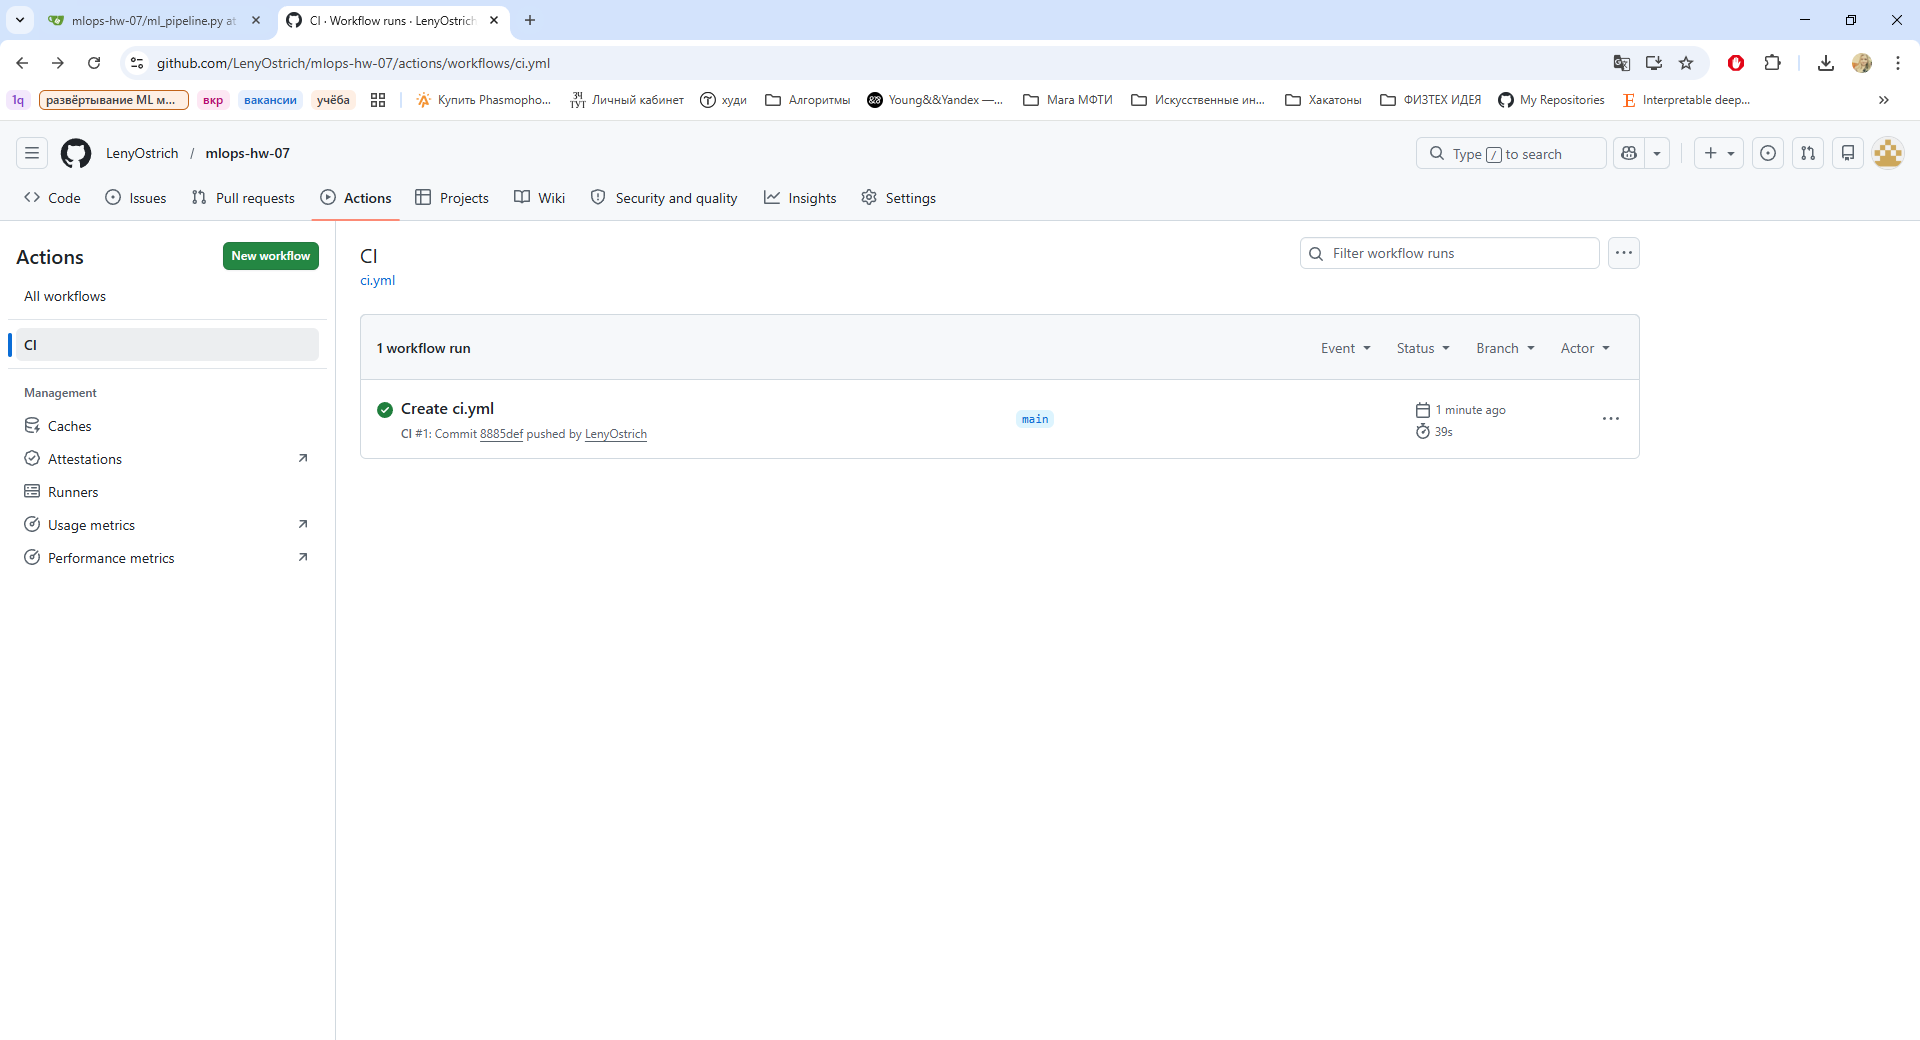

## 6. Итоговое оформление

В итоговых выводах дайте 5–8 предложений о своем опыте работы с инструментами модуля: что оказалось простым, что вызвало трудности, какие выводы сделали по обоснованию стратегии деплоя.



# Ответ


Работа с инструментами модуля показала, что GitHub Actions оказался наиболее простым и удобным решением: он быстро настраивается, не требует дополнительной инфраструктуры и хорошо подходит для небольших ML-проектов. С GitLab возникли сложности с доступом из России, из-за чего полноценное использование CI/CD-пайплайнов оказалось недоступным. Платформа GitVerse также не была использована в полной мере, так как требовала привязки номера телефона, что создало дополнительный барьер. В результате для практики пришлось ориентироваться на альтернативные решения. Gitea показалась достаточно гибкой и понятной, но потребовала ручной настройки runner’ов, что сделало невозможным проверку пайплайнов. В ходе работы стало понятно, что выбор стратегии деплоя напрямую зависит от доступности инфраструктуры и зрелости CI/CD-инструмента. В целом наиболее практичным и понятным решением для учебных задач оказался GitHub Actions.
